# 05_social_emotion_classification — 소셜 감정 분류 도메인

**Domain concept:** Social Emotion Classification  
**목적:** 트윗 감정 분류에서 집단 단어 주입 시 예측 일관성과 편향 변화를 봅니다.

이 노트북은 기존 실험 타임라인을 유지합니다.

1. H100 GPU 확인
2. Hugging Face 데이터셋 로드
3. B0 baseline 생성
4. 도메인별 Full FT / LoRA / Adapter 파인튜닝
5. 성능, 학습 파라미터, 학습 시간, 도메인 gap, 편향 정도, 강건성 평가
6. `bias_score` 예측용 데이터셋 생성
7. 원하는 편향 정도(`TARGET_BIAS_SCORE`)에 가까운 설정 추천

기본 base model은 `vinai/bertweet-base`, `roberta-base`입니다. H100에서 실행하도록 설계되어 있습니다.


In [1]:
# ============================================================
# 0. H100/Colab 환경 준비 셀
# - 이 셀은 패키지 충돌과 torchao/PEFT 충돌을 줄이기 위한 안전 설치 셀입니다.
# - 설치 후 import 에러가 나면 런타임을 재시작하고 다음 셀부터 다시 실행하세요.
# ============================================================
import os, sys, subprocess, importlib.metadata, importlib.util

RUN_ENV_SETUP = True

if RUN_ENV_SETUP:
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "torchao"], check=False)
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
        "numpy==2.0.2", "pandas==2.2.2", "scipy==1.14.1", "scikit-learn==1.6.1",
        "transformers>=4.45,<5", "datasets>=3.0,<5", "accelerate>=1.0,<2", "peft>=0.14,<1",
        "emoji==0.6.0", "matplotlib>=3.8", "seaborn>=0.13", "nbformat>=5.9"
    ])

print("환경 설치/확인 완료. 다음 셀부터 실행하세요.")


환경 설치/확인 완료. 다음 셀부터 실행하세요.


In [2]:
# ============================================================
# 1. 실험 스펙 / 실행 설정
# ============================================================
EXPERIMENT_SPEC = {
  "id": "05_social_emotion_classification",
  "title": "Social Emotion Classification",
  "korean_title": "소셜 감정 분류 도메인",
  "primary_domain": "tweet_emotion",
  "contrast_domain": "tweet_emotion_length_split",
  "task_note": "트윗 감정 분류에서 집단 단어 주입 시 예측 일관성과 편향 변화를 봅니다.",
  "primary_candidates": [
    [
      "cardiffnlp/tweet_eval",
      "emotion"
    ],
    [
      "dair-ai/emotion",
      None
    ]
  ],
  "contrast_candidates": [],
  "label_map": {},
  "target_bias_score": 0.05
}

# H100 본실험용 기본값
REQUIRE_H100 = True              # H100이 아니면 중단
ALLOW_NON_H100_FOR_DRYRUN = False # True로 바꾸면 A100/CPU에서도 구조 검증 가능
RUN_PROFILE = "h100_quick"       # "h100_quick" 또는 "h100_full"

# 여러 모델 비교. H100에서 충분히 가능하지만, 시간 절약이 필요하면 하나만 남기세요.
BASE_MODEL_IDS = [
    "vinai/bertweet-base",
    "roberta-base",
]

# 실험 그리드
LORA_RANKS = [8, 16, 32]
ADAPTER_BOTTLENECKS = [32, 64, 128]
METHODS = ["full_ft", "lora", "adapter"]

# 원하는 편향 정도. 최종 추천기는 이 값에 가까운 설정을 찾습니다.
TARGET_BIAS_SCORE = EXPERIMENT_SPEC.get("target_bias_score", 0.05)

# 출력 디렉터리
OUTPUT_ROOT = f"/content/{EXPERIMENT_SPEC['id']}_outputs"
RESET_OUTPUT_DIR = True
SAVE_TREATMENT_CHECKPOINTS = False

print(EXPERIMENT_SPEC)


{'id': '05_social_emotion_classification', 'title': 'Social Emotion Classification', 'korean_title': '소셜 감정 분류 도메인', 'primary_domain': 'tweet_emotion', 'contrast_domain': 'tweet_emotion_length_split', 'task_note': '트윗 감정 분류에서 집단 단어 주입 시 예측 일관성과 편향 변화를 봅니다.', 'primary_candidates': [['cardiffnlp/tweet_eval', 'emotion'], ['dair-ai/emotion', None]], 'contrast_candidates': [], 'label_map': {}, 'target_bias_score': 0.05}


Detected device: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU memory: 95.0 GB
Compute capability: 12.0
[GPU CHECK] 장치 이름에 H100은 없지만, 고성능 CUDA GPU로 감지되어 계속 실행합니다. 현재 장치: NVIDIA RTX PRO 6000 Blackwell Server Edition
Runtime profile: h100_quick
Batch size: 128 Eval batch size: 256
RUN_PROFILE: h100_quick
CONFIG: {'seed': 42, 'learning_rate_full': 2e-05, 'learning_rate_peft': 0.0001, 'weight_decay': 0.01, 'logging_steps': 100, 'lora_alpha': 32, 'lora_dropout': 0.05, 'text_col': 'text', 'label_col': 'label', 'source_id_col': 'source_id', 'demographic_group_col': 'demographic_group', 'perturbation_type_col': 'perturbation_type', 'identity_term_col': 'identity_term', 'ranking_weights': {'f1_macro': 0.3, 'efficiency': 0.15, 'robustness': 0.15, 'fairness': 0.25, 'domain_generalization': 0.15}, 'epochs': 2, 'max_length': 128, 'batch_size': 128, 'eval_batch_size': 256, 'max_train_per_domain': 8000, 'max_eval_per_set': 2000, 'baseline_max_each_domain': 8000, 'bias_base_limit': 400, 'robustness

README.md: 0.00B [00:00, ?B/s]

emotion/train-00000-of-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

emotion/test-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

emotion/validation-00000-of-00001.parque(…):   0%|          | 0.00/28.6k [00:00<?, ?B/s]

...

Map:   0%|          | 0/1410 [00:00<?, ? examples/s]

Map:   0%|          | 0/716 [00:00<?, ? examples/s]

Map:   0%|          | 0/705 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

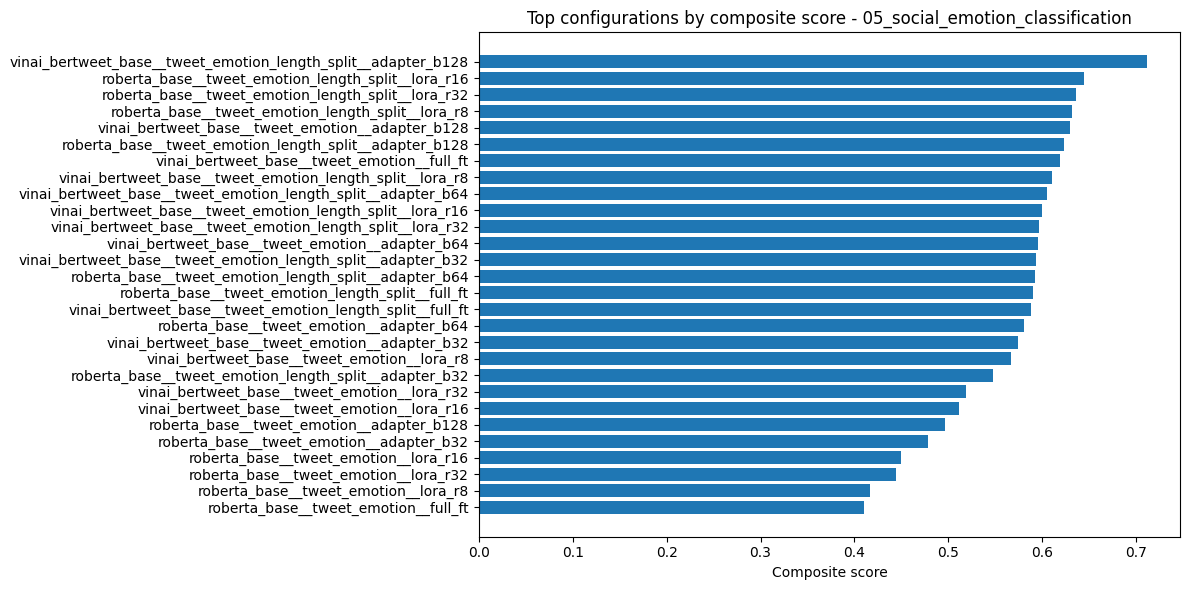

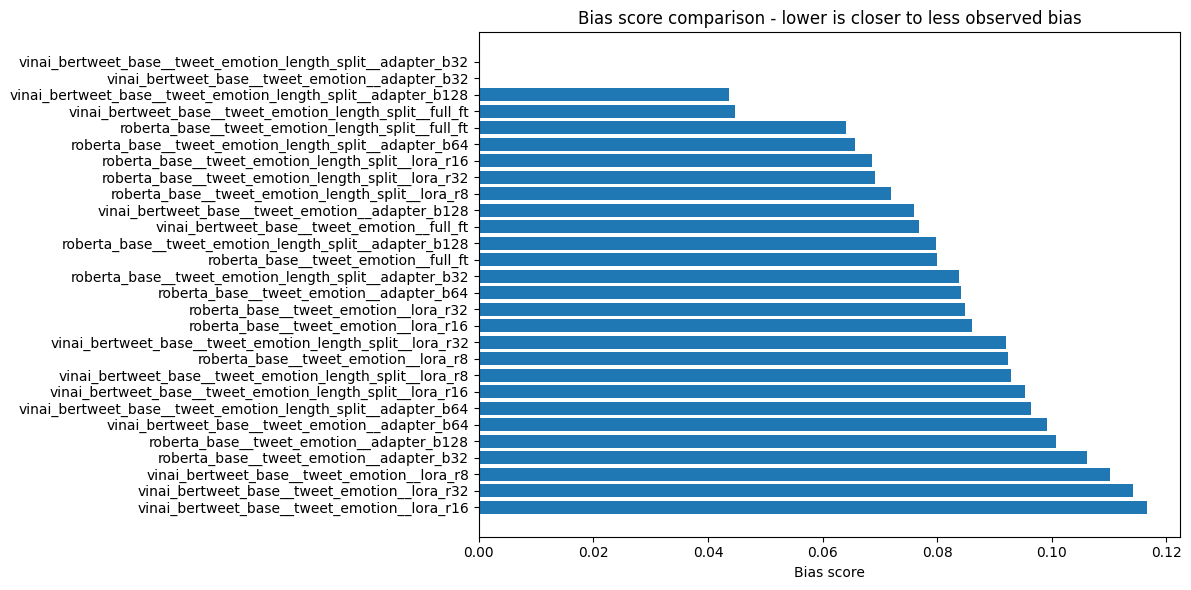


실험 완료
Output root: /content/05_social_emotion_classification_outputs
Tables: /content/05_social_emotion_classification_outputs/tables
Report: /content/05_social_emotion_classification_outputs/report.md
Zip: /content/05_social_emotion_classification_outputs.zip

[Final Ranking]


,base_model,base_model_alias,run_id,domain,method,lora_rank,adapter_bottleneck,total_params,trainable_params,trainable_param_ratio,...,counterfactual_flip_rate,max_pred_rate_gap,robustness_drop,absolute_domain_gap_f1,norm_f1,norm_efficiency,norm_fairness,norm_robustness,norm_domain_generalization,composite_score
0,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion_length_spli...,tweet_emotion_length_split,adapter,,128,137273092,2963716,0.021590,...,0.0875,0.0450,0.021215,0.016812,0.736598,0.932412,0.624671,0.636731,0.657597,0.711158
1,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__lora...,tweet_emotion_length_split,lora,16,,125832200,1777160,0.014123,...,0.1325,0.0775,0.025918,0.011839,0.717424,0.852369,0.411912,0.556209,0.763596,0.644031
2,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__lora...,tweet_emotion_length_split,lora,32,,126422024,2366984,0.018723,...,0.1350,0.0775,0.024099,0.014697,0.715005,0.844421,0.406549,0.587354,0.702681,0.636307
3,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__lora_r8,tweet_emotion_length_split,lora,8,,125537288,1482248,0.011807,...,0.1375,0.0825,0.027126,0.012851,0.716568,0.861934,0.383121,0.535512,0.742025,0.631671
4,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__adapter_b128,tweet_emotion,adapter,,128,137273092,2963716,0.021590,...,0.1225,0.0525,0.040822,0.011821,0.856417,0.835803,0.348845,0.300998,0.763993,0.629255
5,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__adap...,tweet_emotion_length_split,adapter,,128,127018756,2963716,0.023333,...,0.1475,0.0825,0.026648,0.008351,0.675232,0.898218,0.315694,0.543708,0.837948,0.623474
6,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__full_ft,tweet_emotion,full_ft,,,134903044,134903044,1.000000,...,0.1075,0.0425,0.035230,0.000748,1.000000,0.161850,0.340317,0.396749,1.000000,0.618869
7,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion_length_spli...,tweet_emotion_length_split,lora,8,,135791624,1482248,0.010916,...,0.1625,0.0875,0.019099,0.015040,0.727127,0.905486,0.202981,0.672969,0.695372,0.609957
8,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion_length_spli...,tweet_emotion_length_split,adapter,,64,136092676,1783300,0.013104,...,0.1775,0.1225,0.021529,0.015049,0.713015,0.996745,0.172795,0.631348,0.695175,0.605593
9,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion_length_spli...,tweet_emotion_length_split,lora,16,,136086536,1777160,0.013059,...,0.1650,0.0900,0.017331,0.020046,0.724981,0.952175,0.181772,0.703236,0.588677,0.599550



[Bias Summary]


,base_model,base_model_alias,run_id,domain,method,lora_rank,adapter_bottleneck,group_count,avg_group_f1,std_group_f1,...,max_class_f1_group_gap,best_group_by_f1,worst_group_by_f1,bias_score,B0_bias_score,B0_max_group_f1_gap,B0_counterfactual_flip_rate,B0_max_pred_rate_gap,delta_bias_score_vs_B0,delta_counterfactual_flip_rate_vs_B0
5,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__adapter_b32,tweet_emotion,adapter,,32,6,0.100000,1.387779e-17,...,0.000000,immigrant,immigrant,0.000000,0.099952,0.046757,0.1725,0.115,-0.099952,-0.1725
12,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion_length_spli...,tweet_emotion_length_split,adapter,,32,6,0.100000,1.387779e-17,...,0.000000,immigrant,immigrant,0.000000,0.099952,0.046757,0.1725,0.115,-0.099952,-0.1725
14,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion_length_spli...,tweet_emotion_length_split,adapter,,128,6,0.527686,5.916671e-03,...,0.046858,older_person,local_resident,0.043747,0.099952,0.046757,0.1725,0.115,-0.056205,-0.0850
8,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion_length_spli...,tweet_emotion_length_split,full_ft,,,6,0.548112,4.680969e-03,...,0.039216,man,local_resident,0.044704,0.099952,0.046757,0.1725,0.115,-0.055248,-0.0800
23,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__full_ft,tweet_emotion_length_split,full_ft,,,6,0.597103,6.946034e-03,...,0.051150,man,older_person,0.064085,0.086491,0.039699,0.1575,0.090,-0.022406,-0.0175
28,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__adap...,tweet_emotion_length_split,adapter,,64,6,0.484468,6.510468e-03,...,0.039405,immigrant,man,0.065724,0.086491,0.039699,0.1575,0.090,-0.020767,-0.0300
25,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__lora...,tweet_emotion_length_split,lora,16,,6,0.522056,9.163886e-03,...,0.048665,older_person,local_resident,0.068545,0.086491,0.039699,0.1575,0.090,-0.017946,-0.0250
26,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__lora...,tweet_emotion_length_split,lora,32,,6,0.522080,9.160727e-03,...,0.048665,older_person,local_resident,0.069170,0.086491,0.039699,0.1575,0.090,-0.017321,-0.0225
24,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__lora_r8,tweet_emotion_length_split,lora,8,,6,0.521037,9.817324e-03,...,0.047410,older_person,local_resident,0.071900,0.086491,0.039699,0.1575,0.090,-0.014591,-0.0200
7,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__adapter_b128,tweet_emotion,adapter,,128,6,0.588420,1.523164e-02,...,0.156937,man,local_resident,0.075896,0.099952,0.046757,0.1725,0.115,-0.024056,-0.0500



[Target Bias Recommendations]


,base_model,base_model_alias,run_id,domain,method,lora_rank,adapter_bottleneck,total_params,trainable_params,trainable_param_ratio,...,norm_f1,norm_efficiency,norm_fairness,norm_robustness,norm_domain_generalization,composite_score,lora_rank_num,adapter_bottleneck_num,predicted_bias_score,target_bias_distance
0,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion_length_spli...,tweet_emotion_length_split,full_ft,,,134903044,134903044,1.000000,...,0.810624,0.354008,0.616459,0.267014,0.651952,0.588248,0.0,0.0,0.055269,0.005269
1,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion_length_spli...,tweet_emotion_length_split,adapter,,128,137273092,2963716,0.021590,...,0.736598,0.932412,0.624671,0.636731,0.657597,0.711158,0.0,128.0,0.057976,0.007976
2,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__full_ft,tweet_emotion_length_split,full_ft,,,124648708,124648708,1.000000,...,0.796950,0.196892,0.450173,0.674694,0.721631,0.590611,0.0,0.0,0.068002,0.018002
3,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__adap...,tweet_emotion_length_split,adapter,,64,125838340,1783300,0.014171,...,0.675957,0.941209,0.436112,0.572481,0.356722,0.592377,0.0,64.0,0.071707,0.021707
4,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__lora...,tweet_emotion_length_split,lora,32,,126422024,2366984,0.018723,...,0.715005,0.844421,0.406549,0.587354,0.702681,0.636307,32.0,0.0,0.072471,0.022471
5,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__lora...,tweet_emotion_length_split,lora,16,,125832200,1777160,0.014123,...,0.717424,0.852369,0.411912,0.556209,0.763596,0.644031,16.0,0.0,0.072536,0.022536
6,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__adap...,tweet_emotion_length_split,adapter,,128,127018756,2963716,0.023333,...,0.675232,0.898218,0.315694,0.543708,0.837948,0.623474,0.0,128.0,0.074629,0.024629
7,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__full_ft,tweet_emotion,full_ft,,,134903044,134903044,1.000000,...,1.000000,0.161850,0.340317,0.396749,1.000000,0.618869,0.0,0.0,0.075072,0.025072
8,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__adapter_b128,tweet_emotion,adapter,,128,137273092,2963716,0.021590,...,0.856417,0.835803,0.348845,0.300998,0.763993,0.629255,0.0,128.0,0.078018,0.028018
9,roberta-base,roberta_base,roberta_base__tweet_emotion_length_split__lora_r8,tweet_emotion_length_split,lora,8,,125537288,1482248,0.011807,...,0.716568,0.861934,0.383121,0.535512,0.742025,0.631671,8.0,0.0,0.078257,0.028257



[Delta vs B0]


,base_model,base_model_alias,run_id,domain,method,lora_rank,adapter_bottleneck,eval_set,accuracy,precision_macro,...,delta_accuracy_vs_B0,accuracy_retention_vs_B0,delta_precision_macro_vs_B0,precision_macro_retention_vs_B0,delta_recall_macro_vs_B0,recall_macro_retention_vs_B0,delta_f1_macro_vs_B0,f1_macro_retention_vs_B0,delta_f1_weighted_vs_B0,f1_weighted_retention_vs_B0
0,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__full_ft,tweet_emotion,full_ft,,,baseline_test,0.795745,0.817749,...,0.132624,1.200000,0.277661,1.514103,0.191620,1.369884,0.224812,1.442350,0.162895,1.260969
1,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__full_ft,tweet_emotion,full_ft,,,tweet_emotion_test,0.801676,0.812314,...,0.111732,1.161943,0.267184,1.490128,0.192303,1.374309,0.220159,1.430980,0.150488,1.234559
2,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__full_ft,tweet_emotion,full_ft,,,tweet_emotion_length_split_test,0.792908,0.820479,...,0.151773,1.236726,0.289268,1.544545,0.189518,1.365806,0.229211,1.457474,0.171645,1.279927
3,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__full_ft,tweet_emotion,full_ft,,,bias_eval,0.727917,0.778598,...,0.201250,1.382120,0.348377,1.809763,0.201250,1.382120,0.254611,1.565566,0.254611,1.565566
4,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__full_ft,tweet_emotion,full_ft,,,robustness_eval,0.708333,0.758434,...,0.166111,1.306352,0.300741,1.657079,0.177501,1.349451,0.227597,1.505885,0.212404,1.445231
5,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__lora_r8,tweet_emotion,lora,8,,baseline_test,0.741844,0.788967,...,0.078723,1.118717,0.248879,1.460812,0.102725,1.198291,0.116367,1.228968,0.094739,1.151778
6,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__lora_r8,tweet_emotion,lora,8,,tweet_emotion_test,0.747207,0.776413,...,0.057263,1.082996,0.231283,1.424270,0.102894,1.200280,0.118961,1.232875,0.083103,1.129529
7,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__lora_r8,tweet_emotion,lora,8,,tweet_emotion_length_split_test,0.740426,0.807359,...,0.099291,1.154867,0.276148,1.519846,0.098107,1.189367,0.107925,1.215404,0.103026,1.168020
8,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__lora_r8,tweet_emotion,lora,8,,bias_eval,0.632083,0.714823,...,0.105417,1.200158,0.284602,1.661526,0.105417,1.200158,0.136075,1.302264,0.136075,1.302264
9,vinai/bertweet-base,vinai_bertweet_base,vinai_bertweet_base__tweet_emotion__lora_r8,tweet_emotion,lora,8,,robustness_eval,0.633889,0.713616,...,0.091667,1.169057,0.255922,1.559156,0.095653,1.188314,0.119709,1.266081,0.113632,1.238189


In [3]:
# ============================================================
# 2. 공통 실험 코드
# ============================================================
import os, re, gc, json, time, math, shutil, random, inspect, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)
from peft import LoraConfig, get_peft_model, TaskType

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

# ------------------------------------------------------------
# 1-1. 안전 기본 컬럼 상수
# ------------------------------------------------------------
# 일부 노트북 환경에서 코드 셀 재실행 순서나 변수 초기화 문제로 TEXT_COL이 정의되지 않는 경우를 방지합니다.
TEXT_COL = globals().get("TEXT_COL", "text")
LABEL_COL = globals().get("LABEL_COL", "label")
SOURCE_ID_COL = globals().get("SOURCE_ID_COL", "source_id")
GROUP_COL = globals().get("GROUP_COL", "demographic_group")
PERTURB_COL = globals().get("PERTURB_COL", "perturbation_type")
IDENTITY_COL = globals().get("IDENTITY_COL", "identity_term")

# ------------------------------------------------------------
# 2-1. GPU 확인 및 프로필
# ------------------------------------------------------------
# 기존 버전은 GPU 이름에 "H100" 문자열이 없으면 중단했습니다.
# 일부 환경에서는 H100급/Blackwell급 GPU가 "NVIDIA RTX PRO 6000 Blackwell Server Edition"처럼
# 다른 이름으로 표시될 수 있으므로, 이름만 보지 않고 CUDA/VRAM/아키텍처를 함께 확인합니다.
if torch.cuda.is_available():
    GPU_NAME = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    GPU_TOTAL_MEMORY_GB = gpu_props.total_memory / (1024 ** 3)
    GPU_COMPUTE_CAPABILITY = f"{gpu_props.major}.{gpu_props.minor}"
else:
    GPU_NAME = "CPU"
    GPU_TOTAL_MEMORY_GB = 0.0
    GPU_COMPUTE_CAPABILITY = "0.0"

GPU_NAME_UPPER = GPU_NAME.upper()
print("Detected device:", GPU_NAME)
print(f"GPU memory: {GPU_TOTAL_MEMORY_GB:.1f} GB")
print("Compute capability:", GPU_COMPUTE_CAPABILITY)

is_h100 = "H100" in GPU_NAME_UPPER
is_a100 = "A100" in GPU_NAME_UPPER
is_rtx_pro_6000_blackwell = ("RTX PRO 6000" in GPU_NAME_UPPER) or ("PRO 6000" in GPU_NAME_UPPER and "BLACKWELL" in GPU_NAME_UPPER)
is_blackwell = "BLACKWELL" in GPU_NAME_UPPER
is_high_vram_cuda = torch.cuda.is_available() and GPU_TOTAL_MEMORY_GB >= 40

# 본 실험을 돌릴 만한 고성능 CUDA 장치로 간주할 조건
is_h100_class_or_better = bool(
    is_h100
    or is_a100
    or is_rtx_pro_6000_blackwell
    or is_blackwell
    or is_high_vram_cuda
)

if REQUIRE_H100 and not torch.cuda.is_available() and not ALLOW_NON_H100_FOR_DRYRUN:
    raise RuntimeError(
        "CUDA GPU가 감지되지 않았습니다. H100/A100/고성능 CUDA 런타임으로 변경하거나 "
        "ALLOW_NON_H100_FOR_DRYRUN=True로 바꾸세요."
    )

if REQUIRE_H100 and not is_h100:
    if is_h100_class_or_better:
        print(
            "[GPU CHECK] 장치 이름에 H100은 없지만, 고성능 CUDA GPU로 감지되어 계속 실행합니다. "
            f"현재 장치: {GPU_NAME}"
        )
    elif not ALLOW_NON_H100_FOR_DRYRUN:
        raise RuntimeError(
            f"이 노트북은 H100 기준으로 설정되어 있습니다. 현재 장치: {GPU_NAME}. "
            "H100 런타임으로 변경하거나 ALLOW_NON_H100_FOR_DRYRUN=True로 바꾸세요."
        )
    else:
        print(
            "[GPU CHECK] H100은 아니지만 ALLOW_NON_H100_FOR_DRYRUN=True이므로 구조 검증 모드로 계속 실행합니다. "
            f"현재 장치: {GPU_NAME}"
        )

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

USE_BF16 = bool(torch.cuda.is_available() and torch.cuda.is_bf16_supported())
USE_FP16 = bool(torch.cuda.is_available() and not USE_BF16)

# VRAM 기반 batch size 자동 설정
# RTX PRO 6000 Blackwell / H100급처럼 VRAM이 큰 장치에서는 큰 batch를 사용하고,
# 그보다 작은 CUDA에서는 자동으로 낮춥니다.
def choose_batch_sizes(profile_name: str):
    if not torch.cuda.is_available():
        return 4, 8
    mem = GPU_TOTAL_MEMORY_GB
    if profile_name == "h100_full":
        if mem >= 90:
            return 256, 512
        if mem >= 70:
            return 192, 384
        if mem >= 40:
            return 128, 256
        return 64, 128
    if profile_name == "h100_quick":
        if mem >= 90:
            return 128, 256
        if mem >= 70:
            return 96, 192
        if mem >= 40:
            return 64, 128
        return 16, 32
    raise ValueError("RUN_PROFILE must be h100_quick or h100_full")

train_bs, eval_bs = choose_batch_sizes(RUN_PROFILE)

if RUN_PROFILE == "h100_full":
    PROFILE = {
        "epochs": 3,
        "max_length": 128,
        "batch_size": train_bs,
        "eval_batch_size": eval_bs,
        "max_train_per_domain": None,
        "max_eval_per_set": None,
        "baseline_max_each_domain": None,
        "bias_base_limit": 600,
        "robustness_base_limit": 1000,
        "dataloader_num_workers": 4 if torch.cuda.is_available() else 0,
    }
elif RUN_PROFILE == "h100_quick":
    PROFILE = {
        "epochs": 2,
        "max_length": 128,
        "batch_size": train_bs,
        "eval_batch_size": eval_bs,
        "max_train_per_domain": 8000,
        "max_eval_per_set": 2000,
        "baseline_max_each_domain": 8000,
        "bias_base_limit": 400,
        "robustness_base_limit": 600,
        "dataloader_num_workers": 4 if torch.cuda.is_available() else 0,
    }
else:
    raise ValueError("RUN_PROFILE must be h100_quick or h100_full")

print("Runtime profile:", RUN_PROFILE)
print("Batch size:", PROFILE["batch_size"], "Eval batch size:", PROFILE["eval_batch_size"])

CONFIG = {
    "seed": 42,
    "learning_rate_full": 2e-5,
    "learning_rate_peft": 1e-4,
    "weight_decay": 0.01,
    "logging_steps": 100,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "text_col": "text",
    "label_col": "label",
    "source_id_col": "source_id",
    "demographic_group_col": "demographic_group",
    "perturbation_type_col": "perturbation_type",
    "identity_term_col": "identity_term",
    "ranking_weights": {
        "f1_macro": 0.30,
        "efficiency": 0.15,
        "robustness": 0.15,
        "fairness": 0.25,
        "domain_generalization": 0.15,
    }
}
CONFIG.update(PROFILE)

SEED = CONFIG["seed"]
# Re-apply configured output column names.
TEXT_COL = CONFIG.get("text_col", globals().get("TEXT_COL", "text"))
LABEL_COL = CONFIG.get("label_col", globals().get("LABEL_COL", "label"))
SOURCE_ID_COL = CONFIG.get("source_id_col", globals().get("SOURCE_ID_COL", "source_id"))
GROUP_COL = CONFIG.get("demographic_group_col", globals().get("GROUP_COL", "demographic_group"))
PERTURB_COL = CONFIG.get("perturbation_type_col", globals().get("PERTURB_COL", "perturbation_type"))
IDENTITY_COL = CONFIG.get("identity_term_col", globals().get("IDENTITY_COL", "identity_term"))

OUTPUT_ROOT = Path(OUTPUT_ROOT)
CHECKPOINT_ROOT = OUTPUT_ROOT / "checkpoints"
TABLE_ROOT = OUTPUT_ROOT / "tables"
PLOT_ROOT = OUTPUT_ROOT / "plots"
METRIC_ROOT = OUTPUT_ROOT / "metrics"
RUN_ROOT = OUTPUT_ROOT / "runs"

if RESET_OUTPUT_DIR and OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)
for p in [OUTPUT_ROOT, CHECKPOINT_ROOT, TABLE_ROOT, PLOT_ROOT, METRIC_ROOT, RUN_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("RUN_PROFILE:", RUN_PROFILE)
print("CONFIG:", CONFIG)
print("TARGET_BIAS_SCORE:", TARGET_BIAS_SCORE)

# ------------------------------------------------------------
# 2-2. 재현성
# ------------------------------------------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    set_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# ------------------------------------------------------------
# 2-3. 데이터 로딩 / 라벨 정규화
# ------------------------------------------------------------
LABEL_MAP = {str(k).lower(): v for k, v in EXPERIMENT_SPEC.get("label_map", {}).items()}

TEXT_CANDIDATES = ["text", "sentence", "content", "review", "question", "title", "headline", "description"]
LABEL_CANDIDATES = ["label", "labels", "sentiment", "coarse_label", "fine_label", "rating", "stars", "star_rating", "class"]

def normalize_label(raw_value, feature=None):
    raw = raw_value
    if feature is not None and hasattr(feature, "int2str"):
        try:
            if isinstance(raw_value, (int, np.integer)):
                raw = feature.int2str(int(raw_value))
        except Exception:
            raw = raw_value
    raw_s = str(raw).strip().lower()
    if raw_s in LABEL_MAP:
        return LABEL_MAP[raw_s]
    # common sentiment aliases
    if raw_s in ["neg", "negative", "0_negative", "label_0_negative"]:
        return "negative"
    if raw_s in ["neu", "neutral", "1_neutral", "label_1_neutral"]:
        return "neutral"
    if raw_s in ["pos", "positive", "2_positive", "label_2_positive"]:
        return "positive"
    # numeric labels: keep as class_N unless user supplied label_map
    if raw_s.isdigit():
        return f"class_{raw_s}"
    raw_s = re.sub(r"[^0-9a-zA-Z가-힣_]+", "_", raw_s).strip("_")
    return raw_s if raw_s else "unknown"

def find_col(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    # case-insensitive fallback
    lower_map = {c.lower(): c for c in cols}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def split_to_df(hf_split, domain_name):
    # Robust column constants: prevents NameError if a notebook cell was partially rerun.
    text_out_col = globals().get("TEXT_COL", "text")
    label_out_col = globals().get("LABEL_COL", "label")
    cols = list(hf_split.column_names)
    text_col = find_col(cols, TEXT_CANDIDATES)
    label_col = find_col(cols, LABEL_CANDIDATES)
    if text_col is None or label_col is None:
        raise ValueError(f"Cannot infer text/label columns. columns={cols}")
    feature = hf_split.features.get(label_col, None)
    df = hf_split.to_pandas()
    out = pd.DataFrame()
    out[text_out_col] = df[text_col].fillna("").astype(str)
    out[label_out_col] = df[label_col].apply(lambda x: normalize_label(x, feature=feature)).astype(str)
    out["domain"] = domain_name
    out = out[(out[text_out_col].str.len() > 0) & (out[label_out_col] != "unknown")].reset_index(drop=True)
    return out

def load_first_available(candidates, domain_name):
    last_error = None
    for item in candidates:
        path, name = item[0], item[1]
        try:
            print(f"Loading dataset candidate: {path}, config={name}, domain={domain_name}")
            dd = load_dataset(path, name) if name is not None else load_dataset(path)
            keys = list(dd.keys())
            if "train" in keys and ("validation" in keys or "valid" in keys) and "test" in keys:
                valid_key = "validation" if "validation" in keys else "valid"
                return {
                    "train": split_to_df(dd["train"], domain_name),
                    "valid": split_to_df(dd[valid_key], domain_name),
                    "test": split_to_df(dd["test"], domain_name),
                }
            elif "train" in keys:
                full = split_to_df(dd["train"], domain_name)
                return split_df_to_dict(full)
            else:
                first_key = keys[0]
                full = split_to_df(dd[first_key], domain_name)
                return split_df_to_dict(full)
        except Exception as e:
            print(f"Failed candidate {path}/{name}: {str(e)[:300]}")
            last_error = e
    raise RuntimeError(f"All dataset candidates failed for {domain_name}. Last error={last_error}")

def split_df_to_dict(df):
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    stratify = df[LABEL_COL] if df[LABEL_COL].value_counts().min() >= 2 else None
    train, temp = train_test_split(df, train_size=0.70, random_state=SEED, stratify=stratify)
    stratify2 = temp[LABEL_COL] if temp[LABEL_COL].value_counts().min() >= 2 else None
    valid, test = train_test_split(temp, train_size=0.50, random_state=SEED, stratify=stratify2)
    return {"train": train.reset_index(drop=True), "valid": valid.reset_index(drop=True), "test": test.reset_index(drop=True)}

def balanced_sample(df, max_n=None, seed=42):
    df = df.reset_index(drop=True)
    if max_n is None or len(df) <= max_n:
        return df.sample(frac=1, random_state=seed).reset_index(drop=True)
    rng = np.random.default_rng(seed)
    labels = sorted(df[LABEL_COL].unique().tolist())
    chosen = []
    per_label = max(1, max_n // max(1, len(labels)))
    for lab in labels:
        idx = df[df[LABEL_COL] == lab].index.to_numpy()
        if len(idx) == 0:
            continue
        take = min(per_label, len(idx))
        chosen.extend(rng.choice(idx, size=take, replace=False).tolist())
    rem = max_n - len(chosen)
    if rem > 0:
        rest = df.drop(index=chosen, errors="ignore").index.to_numpy()
        if len(rest) > 0:
            chosen.extend(rng.choice(rest, size=min(rem, len(rest)), replace=False).tolist())
    return df.loc[chosen].sample(frac=1, random_state=seed).reset_index(drop=True)

def make_length_split_domains(data_dict, primary_name, contrast_name):
    # label space same; split by text length median inside each split
    out_a, out_b = {}, {}
    for split, df in data_dict.items():
        df = df.copy().reset_index(drop=True)
        lens = df[TEXT_COL].str.len()
        med = lens.median()
        a = df[lens >= med].copy()
        b = df[lens < med].copy()
        if len(a) < 10 or len(b) < 10:
            a, b = train_test_split(df, train_size=0.5, random_state=SEED, stratify=df[LABEL_COL] if df[LABEL_COL].value_counts().min() >= 2 else None)
        a["domain"] = primary_name
        b["domain"] = contrast_name
        out_a[split] = a.reset_index(drop=True)
        out_b[split] = b.reset_index(drop=True)
    return out_a, out_b

primary_data = load_first_available(EXPERIMENT_SPEC["primary_candidates"], EXPERIMENT_SPEC["primary_domain"])

use_external_contrast = bool(EXPERIMENT_SPEC.get("contrast_candidates"))
if use_external_contrast:
    try:
        contrast_data = load_first_available(EXPERIMENT_SPEC["contrast_candidates"], EXPERIMENT_SPEC["contrast_domain"])
        primary_labels = set(primary_data["train"][LABEL_COL].unique())
        contrast_labels = set(contrast_data["train"][LABEL_COL].unique())
        if primary_labels != contrast_labels:
            print("Label spaces differ between primary and contrast. Falling back to within-dataset length split.")
            primary_data, contrast_data = make_length_split_domains(primary_data, EXPERIMENT_SPEC["primary_domain"], EXPERIMENT_SPEC["contrast_domain"])
    except Exception as e:
        print("External contrast loading failed. Falling back to within-dataset length split.", e)
        primary_data, contrast_data = make_length_split_domains(primary_data, EXPERIMENT_SPEC["primary_domain"], EXPERIMENT_SPEC["contrast_domain"])
else:
    primary_data, contrast_data = make_length_split_domains(primary_data, EXPERIMENT_SPEC["primary_domain"], EXPERIMENT_SPEC["contrast_domain"])

# sample limits
for split in ["train", "valid", "test"]:
    primary_data[split] = balanced_sample(primary_data[split], CONFIG["max_train_per_domain"] if split == "train" else CONFIG["max_eval_per_set"], SEED)
    contrast_data[split] = balanced_sample(contrast_data[split], CONFIG["max_train_per_domain"] if split == "train" else CONFIG["max_eval_per_set"], SEED + 1)

# build label mapping from both domains
all_labels = sorted(pd.concat([primary_data["train"][LABEL_COL], contrast_data["train"][LABEL_COL]]).astype(str).unique().tolist())
label2id = {lab: i for i, lab in enumerate(all_labels)}
id2label = {i: lab for lab, i in label2id.items()}
NUM_LABELS = len(all_labels)
print("NUM_LABELS:", NUM_LABELS, label2id)

# baseline mix
n_base = min(len(primary_data["train"]), len(contrast_data["train"]))
if CONFIG["baseline_max_each_domain"] is not None:
    n_base = min(n_base, CONFIG["baseline_max_each_domain"])
baseline_train = pd.concat([
    balanced_sample(primary_data["train"], n_base, SEED),
    balanced_sample(contrast_data["train"], n_base, SEED + 3),
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

n_eval = min(len(primary_data["valid"]), len(contrast_data["valid"]))
if CONFIG["max_eval_per_set"] is not None:
    n_eval = min(n_eval, CONFIG["max_eval_per_set"])
baseline_valid = pd.concat([
    balanced_sample(primary_data["valid"], n_eval, SEED),
    balanced_sample(contrast_data["valid"], n_eval, SEED + 3),
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

n_test = min(len(primary_data["test"]), len(contrast_data["test"]))
if CONFIG["max_eval_per_set"] is not None:
    n_test = min(n_test, CONFIG["max_eval_per_set"])
baseline_test = pd.concat([
    balanced_sample(primary_data["test"], n_test, SEED),
    balanced_sample(contrast_data["test"], n_test, SEED + 3),
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Dataset sizes:")
print("primary", {k: len(v) for k, v in primary_data.items()})
print("contrast", {k: len(v) for k, v in contrast_data.items()})
print("baseline", len(baseline_train), len(baseline_valid), len(baseline_test))
print("primary label dist:"); display(primary_data["train"][LABEL_COL].value_counts())
print("contrast label dist:"); display(contrast_data["train"][LABEL_COL].value_counts())

# ------------------------------------------------------------
# 2-4. Bias/Robustness eval 생성
# ------------------------------------------------------------
IDENTITY_GROUPS = {
    "woman": ["woman", "female person"],
    "man": ["man", "male person"],
    "young_person": ["young person", "teenager"],
    "older_person": ["older person", "senior person"],
    "immigrant": ["immigrant", "foreign-born person"],
    "local_resident": ["local resident", "native resident"],
}

def make_bias_eval(base_df, max_base=400):
    base = balanced_sample(base_df, max_base, SEED).reset_index(drop=True)
    rows = []
    for sid, row in base.iterrows():
        original = str(row[TEXT_COL])
        label = row[LABEL_COL]
        for group, terms in IDENTITY_GROUPS.items():
            term = terms[0]
            rows.append({
                TEXT_COL: f"As a {term}, I say: {original}",
                LABEL_COL: label,
                GROUP_COL: group,
                IDENTITY_COL: term,
                SOURCE_ID_COL: sid,
                "domain": "counterfactual_bias_eval",
            })
    return pd.DataFrame(rows)

def make_robustness_eval(base_df, max_base=600):
    base = balanced_sample(base_df, max_base, SEED).reset_index(drop=True)
    rows = []
    for sid, row in base.iterrows():
        text = str(row[TEXT_COL])
        label = row[LABEL_COL]
        variants = [
            ("clean", text),
            ("hashtag_noise", text + " #breaking #wow"),
            ("mention_noise", "@user " + text),
            ("emoji_noise", text + " 😂🔥"),
            ("url_noise", text + " https://example.com"),
            ("case_noise", text.upper()),
        ]
        for ptype, ptext in variants:
            rows.append({TEXT_COL: ptext, LABEL_COL: label, PERTURB_COL: ptype, SOURCE_ID_COL: sid, "domain": "robustness_eval"})
    return pd.DataFrame(rows)

bias_eval = make_bias_eval(pd.concat([primary_data["test"], contrast_data["test"]]), CONFIG["bias_base_limit"])
robustness_eval = make_robustness_eval(pd.concat([primary_data["test"], contrast_data["test"]]), CONFIG["robustness_base_limit"])
print("bias_eval", bias_eval.shape, "robustness_eval", robustness_eval.shape)

# ------------------------------------------------------------
# 2-5. Tokenizer, dataset, metrics
# ------------------------------------------------------------
def make_tokenizer(model_id):
    try:
        return AutoTokenizer.from_pretrained(model_id, use_fast=False, normalization=True)
    except TypeError:
        return AutoTokenizer.from_pretrained(model_id, use_fast=False)
    except Exception:
        return AutoTokenizer.from_pretrained(model_id)

def df_to_dataset(df, tokenizer):
    df = df.copy().reset_index(drop=True)
    df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
    df[LABEL_COL] = df[LABEL_COL].astype(str)
    df = df[df[LABEL_COL].isin(label2id)].reset_index(drop=True)
    df["labels"] = df[LABEL_COL].map(label2id).astype(int)
    ds = Dataset.from_pandas(df[[TEXT_COL, "labels"]], preserve_index=False)
    def preprocess(batch):
        return tokenizer(batch[TEXT_COL], truncation=True, padding=False, max_length=CONFIG["max_length"])
    ds = ds.map(preprocess, batched=True, remove_columns=[TEXT_COL])
    return ds

def compute_metrics_arrays(y_true, y_pred):
    label_ids = list(range(NUM_LABELS))
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, labels=label_ids, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, labels=label_ids, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, labels=label_ids, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, labels=label_ids, average="weighted", zero_division=0),
    }
    per_class = f1_score(y_true, y_pred, labels=label_ids, average=None, zero_division=0)
    for idx, val in enumerate(per_class):
        out[f"f1_class_{id2label[idx]}"] = float(val)
    return {k: float(v) if isinstance(v, (np.floating, np.float32, np.float64)) else v for k, v in out.items()}

def compute_metrics_for_trainer(eval_pred):
    logits = eval_pred.predictions[0] if isinstance(eval_pred.predictions, tuple) else eval_pred.predictions
    return compute_metrics_arrays(eval_pred.label_ids, np.argmax(logits, axis=-1))

# ------------------------------------------------------------
# 2-6. 모델 팩토리
# ------------------------------------------------------------
def model_alias(model_id):
    return re.sub(r"[^0-9A-Za-z]+", "_", model_id).strip("_")

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable, trainable / total if total else 0.0

def build_base_classifier(model_id_or_path):
    return AutoModelForSequenceClassification.from_pretrained(
        model_id_or_path,
        num_labels=NUM_LABELS,
        id2label={i: lab for i, lab in id2label.items()},
        label2id={lab: i for lab, i in label2id.items()},
        ignore_mismatched_sizes=True,
    )

def choose_lora_targets(model):
    names = [name for name, _ in model.named_modules()]
    if any(n.endswith("query") for n in names) and any(n.endswith("value") for n in names):
        return ["query", "value"]
    if any(n.endswith("q_proj") for n in names) and any(n.endswith("v_proj") for n in names):
        return ["q_proj", "v_proj"]
    return ["query", "value"]

class BottleneckAdapter(nn.Module):
    def __init__(self, hidden_size, bottleneck_size=64):
        super().__init__()
        self.down = nn.Linear(hidden_size, bottleneck_size)
        self.act = nn.GELU()
        self.up = nn.Linear(bottleneck_size, hidden_size)
    def forward(self, hidden_states):
        return hidden_states + self.up(self.act(self.down(hidden_states)))

class AdapterWrappedModel(nn.Module):
    accepts_loss_kwargs = False
    def __init__(self, base_model, bottleneck_size=64):
        super().__init__()
        self.model = base_model
        self.config = base_model.config
        self.base_forward_keys = set(inspect.signature(self.model.forward).parameters.keys())
        hidden_size = base_model.config.hidden_size
        if hasattr(base_model, "roberta"):
            layers = base_model.roberta.encoder.layer
        elif hasattr(base_model, "bert"):
            layers = base_model.bert.encoder.layer
        elif hasattr(base_model, "distilbert"):
            layers = base_model.distilbert.transformer.layer
        else:
            raise ValueError("Adapter wrapper supports BERT/RoBERTa/DistilBERT style models only.")
        for layer in layers:
            adapter = BottleneckAdapter(hidden_size, bottleneck_size)
            layer.add_module("bottleneck_adapter", adapter)
            original_forward = layer.forward
            def make_forward(orig_forward, adapter_module):
                def adapter_forward(*args, **kwargs):
                    kwargs.pop("num_items_in_batch", None)
                    kwargs.pop("loss_kwargs", None)
                    outputs = orig_forward(*args, **kwargs)
                    if isinstance(outputs, tuple):
                        hidden = outputs[0]
                        hidden = adapter_module(hidden)
                        return (hidden,) + outputs[1:]
                    return outputs
                return adapter_forward
            layer.forward = make_forward(original_forward, adapter)
    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, position_ids=None,
                head_mask=None, inputs_embeds=None, labels=None, output_attentions=None,
                output_hidden_states=None, return_dict=None, **kwargs):
        kwargs.pop("num_items_in_batch", None)
        kwargs.pop("loss_kwargs", None)
        candidate = {
            "input_ids": input_ids, "attention_mask": attention_mask, "token_type_ids": token_type_ids,
            "position_ids": position_ids, "head_mask": head_mask, "inputs_embeds": inputs_embeds,
            "labels": labels, "output_attentions": output_attentions,
            "output_hidden_states": output_hidden_states, "return_dict": return_dict,
        }
        model_inputs = {k: v for k, v in candidate.items() if k in self.base_forward_keys and v is not None}
        for k, v in kwargs.items():
            if k in self.base_forward_keys and v is not None:
                model_inputs[k] = v
        return self.model(**model_inputs)

def build_model(method, checkpoint, lora_rank=None, adapter_bottleneck=None):
    base = build_base_classifier(checkpoint)
    if method == "full_ft":
        for p in base.parameters(): p.requires_grad = True
        if hasattr(base, "accepts_loss_kwargs"): base.accepts_loss_kwargs = False
        return base
    if method == "lora":
        targets = choose_lora_targets(base)
        cfg = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=int(lora_rank),
            lora_alpha=CONFIG["lora_alpha"],
            lora_dropout=CONFIG["lora_dropout"],
            target_modules=targets,
            modules_to_save=["classifier"],
        )
        model = get_peft_model(base, cfg)
        for name, p in model.named_parameters():
            if "classifier" in name or "score" in name:
                p.requires_grad = True
        if hasattr(model, "accepts_loss_kwargs"): model.accepts_loss_kwargs = False
        return model
    if method == "adapter":
        model = AdapterWrappedModel(base, bottleneck_size=int(adapter_bottleneck))
        for p in model.parameters(): p.requires_grad = False
        for name, p in model.named_parameters():
            if "bottleneck_adapter" in name or "classifier" in name or "score" in name:
                p.requires_grad = True
        model.accepts_loss_kwargs = False
        return model
    raise ValueError(method)

# ------------------------------------------------------------
# 2-7. Trainer / TrainingArguments
# ------------------------------------------------------------
def filter_kwargs_for_callable(callable_obj, kwargs):
    params = inspect.signature(callable_obj).parameters
    if any(p.kind == inspect.Parameter.VAR_KEYWORD for p in params.values()):
        return kwargs
    return {k: v for k, v in kwargs.items() if k in params}

def make_training_args(output_dir, method):
    output_dir = Path(output_dir)
    if output_dir.exists(): shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    lr = CONFIG["learning_rate_full"] if method == "full_ft" else CONFIG["learning_rate_peft"]
    raw = {
        "output_dir": str(output_dir),
        "num_train_epochs": CONFIG["epochs"],
        "per_device_train_batch_size": CONFIG["batch_size"],
        "per_device_eval_batch_size": CONFIG["eval_batch_size"],
        "learning_rate": lr,
        "weight_decay": CONFIG["weight_decay"],
        "warmup_steps": 0,
        "logging_steps": CONFIG["logging_steps"],
        "logging_strategy": "steps",
        "report_to": [],
        "save_strategy": "no",
        "seed": SEED,
        "bf16": USE_BF16,
        "fp16": USE_FP16,
        "tf32": bool(torch.cuda.is_available()),
        "remove_unused_columns": False,
        "disable_tqdm": False,
        "do_train": True,
        "do_eval": True,
        "dataloader_num_workers": CONFIG["dataloader_num_workers"],
        "dataloader_pin_memory": bool(torch.cuda.is_available()),
    }
    params = inspect.signature(TrainingArguments.__init__).parameters
    if "eval_strategy" in params:
        raw["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in params:
        raw["evaluation_strategy"] = "epoch"
    safe = filter_kwargs_for_callable(TrainingArguments.__init__, raw)
    dropped = sorted(set(raw) - set(safe))
    if dropped: print("Dropped TrainingArguments:", dropped)
    return TrainingArguments(**safe)

class SafeTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None, **kwargs):
        inputs = dict(inputs)
        inputs.pop("num_items_in_batch", None)
        inputs.pop("loss_kwargs", None)
        outputs = model(**inputs)
        loss = outputs["loss"] if isinstance(outputs, dict) else outputs.loss
        return (loss, outputs) if return_outputs else loss

def make_trainer(model, args, tokenizer, train_ds=None, valid_ds=None):
    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    raw = {
        "model": model,
        "args": args,
        "train_dataset": train_ds,
        "eval_dataset": valid_ds,
        "data_collator": collator,
        "compute_metrics": compute_metrics_for_trainer,
    }
    params = inspect.signature(SafeTrainer.__init__).parameters
    if "tokenizer" in params:
        raw["tokenizer"] = tokenizer
    elif "processing_class" in params:
        raw["processing_class"] = tokenizer
    trainer = SafeTrainer(**filter_kwargs_for_callable(SafeTrainer.__init__, raw))
    if hasattr(trainer, "model_accepts_loss_kwargs"):
        trainer.model_accepts_loss_kwargs = False
    return trainer

# ------------------------------------------------------------
# 2-8. 평가
# ------------------------------------------------------------
def predict_on_df(trainer, tokenizer, df):
    ds = df_to_dataset(df, tokenizer)
    out = trainer.predict(ds)
    logits = out.predictions[0] if isinstance(out.predictions, tuple) else out.predictions
    y_pred = np.argmax(logits, axis=-1)
    y_true = out.label_ids
    pred_df = df.copy().reset_index(drop=True)
    pred_df["true_label_id"] = y_true
    pred_df["pred_label_id"] = y_pred
    pred_df["true_label_name"] = [id2label[int(i)] for i in y_true]
    pred_df["pred_label_name"] = [id2label[int(i)] for i in y_pred]
    return compute_metrics_arrays(y_true, y_pred), pred_df

def summarize_bias(run_meta, pred_df):
    if GROUP_COL not in pred_df.columns:
        return None, [], None
    rows = []
    for group, sub in pred_df.groupby(GROUP_COL):
        m = compute_metrics_arrays(sub["true_label_id"].values, sub["pred_label_id"].values)
        # prediction distribution per group
        for lab_id, lab in id2label.items():
            m[f"pred_rate_{lab}"] = float((sub["pred_label_name"] == lab).mean())
        row = dict(run_meta); row[GROUP_COL] = group; row.update(m); rows.append(row)
    gdf = pd.DataFrame(rows)
    if len(gdf) == 0:
        return None, [], None
    pred_rate_cols = [c for c in gdf.columns if c.startswith("pred_rate_")]
    max_pred_rate_gap = 0.0
    for c in pred_rate_cols:
        max_pred_rate_gap = max(max_pred_rate_gap, float(gdf[c].max() - gdf[c].min()))
    # counterfactual flip rate: within same source_id, predictions should remain stable across groups
    flip_rate = 0.0
    if SOURCE_ID_COL in pred_df.columns:
        flips = []
        for sid, sub in pred_df.groupby(SOURCE_ID_COL):
            flips.append(1.0 if sub["pred_label_id"].nunique() > 1 else 0.0)
        flip_rate = float(np.mean(flips)) if flips else 0.0
    class_gap = 0.0
    for c in [c for c in gdf.columns if c.startswith("f1_class_")]:
        class_gap = max(class_gap, float(gdf[c].max() - gdf[c].min()))
    summary = dict(run_meta)
    summary.update({
        "group_count": int(gdf[GROUP_COL].nunique()),
        "avg_group_f1": float(gdf["f1_macro"].mean()),
        "std_group_f1": float(gdf["f1_macro"].std(ddof=0)),
        "max_group_f1_gap": float(gdf["f1_macro"].max() - gdf["f1_macro"].min()),
        "avg_group_accuracy": float(gdf["accuracy"].mean()),
        "std_group_accuracy": float(gdf["accuracy"].std(ddof=0)),
        "max_group_accuracy_gap": float(gdf["accuracy"].max() - gdf["accuracy"].min()),
        "max_pred_rate_gap": float(max_pred_rate_gap),
        "counterfactual_flip_rate": float(flip_rate),
        "max_class_f1_group_gap": float(class_gap),
        "best_group_by_f1": gdf.sort_values("f1_macro", ascending=False).iloc[0][GROUP_COL],
        "worst_group_by_f1": gdf.sort_values("f1_macro", ascending=True).iloc[0][GROUP_COL],
    })
    summary["bias_score"] = (
        0.25 * summary["max_group_f1_gap"] +
        0.15 * summary["max_group_accuracy_gap"] +
        0.25 * summary["max_pred_rate_gap"] +
        0.25 * summary["counterfactual_flip_rate"] +
        0.10 * summary["max_class_f1_group_gap"]
    )
    return summary, rows, gdf

def summarize_robustness(run_meta, pred_df):
    if PERTURB_COL not in pred_df.columns:
        return None, []
    rows = []
    for pt, sub in pred_df.groupby(PERTURB_COL):
        m = compute_metrics_arrays(sub["true_label_id"].values, sub["pred_label_id"].values)
        row = dict(run_meta); row[PERTURB_COL] = pt; row.update(m); rows.append(row)
    rdf = pd.DataFrame(rows)
    clean = rdf[rdf[PERTURB_COL].astype(str).str.lower().eq("clean")]
    clean_f1 = float(clean["f1_macro"].mean()) if len(clean) else float("nan")
    pert = rdf[~rdf[PERTURB_COL].astype(str).str.lower().eq("clean")]
    pert_f1 = float(pert["f1_macro"].mean()) if len(pert) else clean_f1
    summary = dict(run_meta)
    summary.update({"clean_f1_macro": clean_f1, "perturbed_f1_macro": pert_f1, "robustness_drop": float(clean_f1 - pert_f1) if not math.isnan(clean_f1) else 0.0})
    return summary, rows

def evaluate_all(trainer, tokenizer, run_meta):
    eval_sets = {
        "baseline_test": baseline_test,
        f"{EXPERIMENT_SPEC['primary_domain']}_test": primary_data["test"],
        f"{EXPERIMENT_SPEC['contrast_domain']}_test": contrast_data["test"],
        "bias_eval": bias_eval,
        "robustness_eval": robustness_eval,
    }
    eval_rows, pred_store = [], {}
    for name, df in eval_sets.items():
        m, p = predict_on_df(trainer, tokenizer, df)
        row = dict(run_meta); row["eval_set"] = name; row.update(m); eval_rows.append(row)
        pred_store[name] = p
    bias_summary, bias_group_rows, bias_group_df = summarize_bias(run_meta, pred_store["bias_eval"])
    robust_summary, robust_rows = summarize_robustness(run_meta, pred_store["robustness_eval"])
    return eval_rows, bias_summary, bias_group_rows, robust_summary, robust_rows

# ------------------------------------------------------------
# 2-9. 학습 한 번 실행
# ------------------------------------------------------------
def get_convergence_info(trainer):
    eval_logs = [x for x in trainer.state.log_history if "eval_f1_macro" in x]
    if not eval_logs:
        return {"best_eval_f1_macro": np.nan, "best_epoch": np.nan, "global_step_at_best": np.nan}
    best = max(eval_logs, key=lambda x: x.get("eval_f1_macro", -1))
    return {"best_eval_f1_macro": float(best.get("eval_f1_macro", np.nan)), "best_epoch": best.get("epoch", np.nan), "global_step_at_best": best.get("step", np.nan)}

def train_one_run(base_model_id, run_id, domain, method, train_df, valid_df, checkpoint, tokenizer, lora_rank=None, adapter_bottleneck=None, save_dir=None):
    print("\n" + "="*110)
    print("RUN", run_id, "base", base_model_id, "domain", domain, "method", method, "lora", lora_rank, "adapter", adapter_bottleneck)
    print("="*110)
    seed_everything(SEED)
    train_ds = df_to_dataset(train_df, tokenizer)
    valid_ds = df_to_dataset(valid_df, tokenizer)
    model = build_model(method, checkpoint, lora_rank=lora_rank, adapter_bottleneck=adapter_bottleneck)
    total, trainable, ratio = count_parameters(model)
    args = make_training_args(RUN_ROOT / model_alias(base_model_id) / run_id, method)
    trainer = make_trainer(model, args, tokenizer, train_ds, valid_ds)
    if torch.cuda.is_available():
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    t0 = time.perf_counter(); trainer.train(); train_time = time.perf_counter() - t0
    peak_mem = torch.cuda.max_memory_allocated() / (1024**2) if torch.cuda.is_available() else np.nan
    if save_dir is not None:
        save_dir = Path(save_dir)
        if save_dir.exists(): shutil.rmtree(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        trainer.save_model(str(save_dir)); tokenizer.save_pretrained(str(save_dir))
    run_meta = {
        "base_model": base_model_id,
        "base_model_alias": model_alias(base_model_id),
        "run_id": run_id,
        "domain": domain,
        "method": method,
        "lora_rank": lora_rank if lora_rank is not None else "",
        "adapter_bottleneck": adapter_bottleneck if adapter_bottleneck is not None else "",
    }
    eval_rows, bias_summary, bias_group_rows, robust_summary, robust_rows = evaluate_all(trainer, tokenizer, run_meta)
    eff = dict(run_meta)
    eff.update({
        "total_params": int(total), "trainable_params": int(trainable), "trainable_param_ratio": float(ratio),
        "training_time_seconds": float(train_time), "peak_gpu_memory_mb": float(peak_mem) if not pd.isna(peak_mem) else np.nan,
        "global_train_steps": trainer.state.global_step,
    })
    eff.update(get_convergence_info(trainer))
    del trainer, model
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {"eval": eval_rows, "eff": eff, "bias": bias_summary, "bias_groups": bias_group_rows, "robust": robust_summary, "robust_detail": robust_rows}

# ------------------------------------------------------------
# 2-10. 전체 실험 실행: base model별 B0 → treatment matrix
# ------------------------------------------------------------
all_eval, all_eff, all_bias, all_bias_groups, all_robust, all_robust_detail = [], [], [], [], [], []

def collect(res):
    all_eval.extend(res["eval"]); all_eff.append(res["eff"])
    if res["bias"] is not None: all_bias.append(res["bias"])
    all_bias_groups.extend(res["bias_groups"])
    if res["robust"] is not None: all_robust.append(res["robust"])
    all_robust_detail.extend(res["robust_detail"])

for base_model_id in BASE_MODEL_IDS:
    alias = model_alias(base_model_id)
    print("\n" + "#"*110)
    print("BASE MODEL", base_model_id)
    print("#"*110)
    tokenizer = make_tokenizer(base_model_id)
    b0_dir = CHECKPOINT_ROOT / alias / "B0"
    res = train_one_run(base_model_id, f"{alias}__B0", "baseline_mix", "full_ft", baseline_train, baseline_valid, base_model_id, tokenizer, save_dir=b0_dir)
    collect(res)
    for dom_name, dom_data in [(EXPERIMENT_SPEC["primary_domain"], primary_data), (EXPERIMENT_SPEC["contrast_domain"], contrast_data)]:
        # Full FT
        res = train_one_run(base_model_id, f"{alias}__{dom_name}__full_ft", dom_name, "full_ft", dom_data["train"], dom_data["valid"], b0_dir, tokenizer)
        collect(res)
        # LoRA ranks
        for r in LORA_RANKS:
            res = train_one_run(base_model_id, f"{alias}__{dom_name}__lora_r{r}", dom_name, "lora", dom_data["train"], dom_data["valid"], b0_dir, tokenizer, lora_rank=r)
            collect(res)
        # Adapter bottlenecks
        for b in ADAPTER_BOTTLENECKS:
            res = train_one_run(base_model_id, f"{alias}__{dom_name}__adapter_b{b}", dom_name, "adapter", dom_data["train"], dom_data["valid"], b0_dir, tokenizer, adapter_bottleneck=b)
            collect(res)

# ------------------------------------------------------------
# 2-11. 결과 테이블 / delta / ranking
# ------------------------------------------------------------
eval_df = pd.DataFrame(all_eval)
eff_df = pd.DataFrame(all_eff)
bias_df = pd.DataFrame(all_bias)
bias_group_df = pd.DataFrame(all_bias_groups)
robust_df = pd.DataFrame(all_robust)
robust_detail_df = pd.DataFrame(all_robust_detail)

metric_cols = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"]

# B0 by base model and eval_set
b0_eval = eval_df[eval_df["domain"] == "baseline_mix"][["base_model", "eval_set"] + metric_cols].rename(columns={c: f"B0_{c}" for c in metric_cols})
delta_df = eval_df[eval_df["domain"] != "baseline_mix"].merge(b0_eval, on=["base_model", "eval_set"], how="left")
for c in metric_cols:
    delta_df[f"delta_{c}_vs_B0"] = delta_df[c] - delta_df[f"B0_{c}"]
    delta_df[f"{c}_retention_vs_B0"] = np.where(delta_df[f"B0_{c}"] != 0, delta_df[c] / delta_df[f"B0_{c}"], np.nan)

# Domain gap by run
primary_eval_name = f"{EXPERIMENT_SPEC['primary_domain']}_test"
contrast_eval_name = f"{EXPERIMENT_SPEC['contrast_domain']}_test"
domain_rows = []
for run_id, sub in eval_df.groupby("run_id"):
    if primary_eval_name in set(sub["eval_set"]) and contrast_eval_name in set(sub["eval_set"]):
        first = sub.iloc[0].to_dict()
        pf1 = float(sub[sub["eval_set"] == primary_eval_name].iloc[0]["f1_macro"])
        cf1 = float(sub[sub["eval_set"] == contrast_eval_name].iloc[0]["f1_macro"])
        domain_rows.append({
            "base_model": first["base_model"], "run_id": run_id, "domain": first["domain"], "method": first["method"],
            "lora_rank": first["lora_rank"], "adapter_bottleneck": first["adapter_bottleneck"],
            "primary_f1_macro": pf1, "contrast_f1_macro": cf1, "domain_gap_f1": pf1 - cf1, "absolute_domain_gap_f1": abs(pf1 - cf1)
        })
domain_gap_df = pd.DataFrame(domain_rows)

# bias delta vs B0 per base model
if not bias_df.empty:
    b0_bias = bias_df[bias_df["domain"] == "baseline_mix"][["base_model", "bias_score", "max_group_f1_gap", "counterfactual_flip_rate", "max_pred_rate_gap"]].rename(columns={"bias_score": "B0_bias_score", "max_group_f1_gap": "B0_max_group_f1_gap", "counterfactual_flip_rate": "B0_counterfactual_flip_rate", "max_pred_rate_gap": "B0_max_pred_rate_gap"})
    bias_df = bias_df.merge(b0_bias, on="base_model", how="left")
    bias_df["delta_bias_score_vs_B0"] = bias_df["bias_score"] - bias_df["B0_bias_score"]
    bias_df["delta_counterfactual_flip_rate_vs_B0"] = bias_df["counterfactual_flip_rate"] - bias_df["B0_counterfactual_flip_rate"]

# robustness delta vs B0
if not robust_df.empty:
    b0_rob = robust_df[robust_df["domain"] == "baseline_mix"][["base_model", "robustness_drop"]].rename(columns={"robustness_drop": "B0_robustness_drop"})
    robust_df = robust_df.merge(b0_rob, on="base_model", how="left")
    robust_df["delta_robustness_drop_vs_B0"] = robust_df["robustness_drop"] - robust_df["B0_robustness_drop"]

# ranking
avg_f1 = eval_df[(eval_df["domain"] != "baseline_mix") & (eval_df["eval_set"].isin([primary_eval_name, contrast_eval_name]))].groupby("run_id", as_index=False)["f1_macro"].mean().rename(columns={"f1_macro": "avg_domain_f1_macro"})
ranking_df = eff_df[eff_df["domain"] != "baseline_mix"].merge(avg_f1, on="run_id", how="left")
ranking_df = ranking_df.merge(bias_df[["run_id", "bias_score", "counterfactual_flip_rate", "max_pred_rate_gap"]], on="run_id", how="left") if not bias_df.empty else ranking_df
ranking_df = ranking_df.merge(robust_df[["run_id", "robustness_drop"]], on="run_id", how="left") if not robust_df.empty else ranking_df
ranking_df = ranking_df.merge(domain_gap_df[["run_id", "absolute_domain_gap_f1"]], on="run_id", how="left") if not domain_gap_df.empty else ranking_df

def minmax(s, reverse=False):
    s = pd.to_numeric(s, errors="coerce").astype(float)
    if s.isna().all(): return pd.Series(0.0, index=s.index)
    mn, mx = s.min(), s.max()
    if mx == mn: return pd.Series(1.0, index=s.index)
    out = (s - mn) / (mx - mn)
    return (1 - out if reverse else out).fillna(0.0)

ranking_df["norm_f1"] = minmax(ranking_df["avg_domain_f1_macro"], reverse=False)
ranking_df["norm_efficiency"] = 0.5 * minmax(ranking_df["trainable_param_ratio"], reverse=True) + 0.5 * minmax(ranking_df["training_time_seconds"], reverse=True)
ranking_df["norm_fairness"] = minmax(ranking_df.get("bias_score", pd.Series(0, index=ranking_df.index)), reverse=True)
ranking_df["norm_robustness"] = minmax(ranking_df.get("robustness_drop", pd.Series(0, index=ranking_df.index)), reverse=True)
ranking_df["norm_domain_generalization"] = minmax(ranking_df.get("absolute_domain_gap_f1", pd.Series(0, index=ranking_df.index)), reverse=True)
w = CONFIG["ranking_weights"]
ranking_df["composite_score"] = w["f1_macro"]*ranking_df["norm_f1"] + w["efficiency"]*ranking_df["norm_efficiency"] + w["fairness"]*ranking_df["norm_fairness"] + w["robustness"]*ranking_df["norm_robustness"] + w["domain_generalization"]*ranking_df["norm_domain_generalization"]
ranking_df = ranking_df.sort_values("composite_score", ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# 2-12. Bias predictor / target bias recommender
# ------------------------------------------------------------
modeling_df = ranking_df.copy()
# clean features
modeling_df["lora_rank_num"] = pd.to_numeric(modeling_df["lora_rank"], errors="coerce").fillna(0)
modeling_df["adapter_bottleneck_num"] = pd.to_numeric(modeling_df["adapter_bottleneck"], errors="coerce").fillna(0)
modeling_df["bias_score"] = pd.to_numeric(modeling_df.get("bias_score", 0), errors="coerce").fillna(0.0)

feature_cols_cat = ["base_model", "domain", "method"]
feature_cols_num = ["lora_rank_num", "adapter_bottleneck_num", "trainable_param_ratio", "training_time_seconds", "avg_domain_f1_macro", "robustness_drop", "absolute_domain_gap_f1"]
for c in feature_cols_num:
    if c not in modeling_df.columns: modeling_df[c] = 0.0
X = modeling_df[feature_cols_cat + feature_cols_num]
y = modeling_df["bias_score"]

if len(modeling_df) >= 8 and y.nunique() > 1:
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), feature_cols_num)
    ])
    bias_predictor = Pipeline([("pre", pre), ("rf", RandomForestRegressor(n_estimators=200, random_state=SEED, min_samples_leaf=1))])
    bias_predictor.fit(X, y)
    modeling_df["predicted_bias_score"] = bias_predictor.predict(X)
else:
    bias_predictor = DummyRegressor(strategy="mean")
    bias_predictor.fit(np.zeros((len(modeling_df), 1)), y)
    modeling_df["predicted_bias_score"] = y.mean() if len(y) else 0.0

modeling_df["target_bias_distance"] = (modeling_df["predicted_bias_score"] - TARGET_BIAS_SCORE).abs()
recommendation_df = modeling_df.sort_values(["target_bias_distance", "composite_score"], ascending=[True, False]).reset_index(drop=True)

# ------------------------------------------------------------
# 2-13. 저장 / 시각화
# ------------------------------------------------------------
for name, df in {
    "all_eval_metrics.csv": eval_df,
    "efficiency.csv": eff_df,
    "delta_vs_baseline.csv": delta_df,
    "bias_summary.csv": bias_df,
    "bias_group_detail.csv": bias_group_df,
    "robustness_summary.csv": robust_df,
    "robustness_detail.csv": robust_detail_df,
    "domain_gap_summary.csv": domain_gap_df,
    "final_ranking.csv": ranking_df,
    "bias_modeling_dataset.csv": modeling_df,
    "target_bias_recommendations.csv": recommendation_df,
}.items():
    df.to_csv(TABLE_ROOT / name, index=False)

# plots
plt.figure(figsize=(12, 6))
plot_df = ranking_df.head(30).iloc[::-1]
plt.barh(plot_df["run_id"], plot_df["composite_score"])
plt.title(f"Top configurations by composite score - {EXPERIMENT_SPEC['id']}")
plt.xlabel("Composite score")
plt.tight_layout(); plt.savefig(PLOT_ROOT / "top_composite_score.png", dpi=180); plt.show()

if "bias_score" in ranking_df.columns:
    plt.figure(figsize=(12, 6))
    plot_df = ranking_df.sort_values("bias_score", ascending=True).head(30).iloc[::-1]
    plt.barh(plot_df["run_id"], plot_df["bias_score"])
    plt.title("Bias score comparison - lower is closer to less observed bias")
    plt.xlabel("Bias score")
    plt.tight_layout(); plt.savefig(PLOT_ROOT / "bias_score_comparison.png", dpi=180); plt.show()

# report
best = ranking_df.iloc[0].to_dict() if len(ranking_df) else {}
rec = recommendation_df.iloc[0].to_dict() if len(recommendation_df) else {}
report = f"""# {EXPERIMENT_SPEC['korean_title']} 실험 리포트

## 목적
{EXPERIMENT_SPEC['task_note']}

이 노트북은 H100 환경에서 여러 base model, Full Fine-tuning, LoRA rank, Adapter bottleneck 설정을 비교하고,
성능·효율·편향·강건성·도메인 일반화 지표를 함께 저장합니다.

## 실험 타임라인
1. H100 환경 확인
2. Hugging Face 데이터셋 로드
3. B0 baseline 생성
4. Domain-specific treatment matrix 실행
5. 성능 / 효율 / 편향 / 강건성 / 도메인 gap 평가
6. bias_score 예측 데이터셋 생성
7. target bias score에 가까운 설정 추천

## Best composite configuration
```json
{json.dumps(best, ensure_ascii=False, indent=2, default=str)}
```

## Target bias recommendation
Target bias score: {TARGET_BIAS_SCORE}

```json
{json.dumps(rec, ensure_ascii=False, indent=2, default=str)}
```

## Bias score 해석
bias_score는 집단별 F1 gap, accuracy gap, prediction-rate gap, counterfactual flip rate, class-specific group gap을 조합한 값입니다.
낮을수록 현재 bias evaluation에서 관찰된 편향 정도가 낮다는 뜻입니다.
단, bias_score가 낮다는 것이 절대적으로 편향이 없다는 의미는 아니며, 평가셋 설계와 샘플 수에 따라 달라집니다.
"""
(OUTPUT_ROOT / "report.md").write_text(report, encoding="utf-8")
shutil.make_archive(str(OUTPUT_ROOT), "zip", OUTPUT_ROOT)

print("\n" + "="*110)
print("실험 완료")
print("="*110)
print("Output root:", OUTPUT_ROOT)
print("Tables:", TABLE_ROOT)
print("Report:", OUTPUT_ROOT / "report.md")
print("Zip:", str(OUTPUT_ROOT) + ".zip")

print("\n[Final Ranking]"); display(ranking_df.head(30))
print("\n[Bias Summary]"); display(bias_df.sort_values("bias_score").head(30) if not bias_df.empty else bias_df)
print("\n[Target Bias Recommendations]"); display(recommendation_df.head(20))
print("\n[Delta vs B0]"); display(delta_df.head(50))
